# Importing Data

In [1]:
!pip install -q kaggle

In [2]:
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import glob


# Download latest version
path = kagglehub.dataset_download("camnugent/sandp500")

print("Path to dataset files:", path)

100%|██████████| 19.3M/19.3M [00:00<00:00, 135MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/camnugent/sandp500/versions/4


In [3]:
downloaded_files = glob.glob(os.path.join(path, "*.csv"))

if not downloaded_files:
    print(f"No CSV files found directly in '{path}'. Checking subdirectories...")
    downloaded_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

if len(downloaded_files) == 1:
    csv_file_path = downloaded_files[0]
    print(f"Found a single CSV file: {csv_file_path}")
    df = pandas.read_csv(csv_file_path)
    print("\nDataFrame head:")
    print(df.head())

Found a single CSV file: /root/.cache/kagglehub/datasets/camnugent/sandp500/versions/4/all_stocks_5yr.csv

DataFrame head:
         date   open   high    low  close    volume Name
0  2013-02-08  15.07  15.12  14.63  14.75   8407500  AAL
1  2013-02-11  14.89  15.01  14.26  14.46   8882000  AAL
2  2013-02-12  14.45  14.51  14.10  14.27   8126000  AAL
3  2013-02-13  14.30  14.94  14.25  14.66  10259500  AAL
4  2013-02-14  14.94  14.96  13.16  13.99  31879900  AAL


# Describing Data

In [4]:
data_types = df.dtypes
print("Data types of each column:")
print(data_types)

Data types of each column:
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
Name       object
dtype: object


In [5]:
RecordNumber = df.shape[0]
print("Number of records in the DataFrame:", RecordNumber)

Number of records in the DataFrame: 619040


In [6]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

print("--- Range and Average for Numeric Columns (excluding 'date' and 'Name') ---")
for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    average_val = df[col].mean()
    print(f"\nColumn: '{col}'")
    print(f"  Min Value: {min_val:.2f}")
    print(f"  Max Value: {max_val:.2f}")
    print(f"  Range (Max - Min): {max_val - min_val:.2f}")
    print(f"  Average: {average_val:.2f}")

--- Range and Average for Numeric Columns (excluding 'date' and 'Name') ---

Column: 'open'
  Min Value: 1.62
  Max Value: 2044.00
  Range (Max - Min): 2042.38
  Average: 83.02

Column: 'high'
  Min Value: 1.69
  Max Value: 2067.99
  Range (Max - Min): 2066.30
  Average: 83.78

Column: 'low'
  Min Value: 1.50
  Max Value: 2035.11
  Range (Max - Min): 2033.61
  Average: 82.26

Column: 'close'
  Min Value: 1.59
  Max Value: 2049.00
  Range (Max - Min): 2047.41
  Average: 83.04

Column: 'volume'
  Min Value: 0.00
  Max Value: 618237630.00
  Range (Max - Min): 618237630.00
  Average: 4321823.40


In [7]:
null_rows = df[df.isnull().any(axis=1)]
print("Rows with null values:")
print(null_rows)

Rows with null values:
              date  open   high    low     close   volume  Name
82949   2017-07-26   NaN    NaN    NaN   69.0842        3   BHF
165734  2015-07-17   NaN  88.76  88.24   88.7200  2056819   DHR
165857  2016-01-12   NaN    NaN    NaN   88.5500        0   DHR
205076  2015-07-17   NaN  48.49  47.85   47.9200  1246786    ES
239832  2016-07-01   NaN    NaN    NaN   49.5400        0   FTV
434379  2015-07-17   NaN  47.31  46.83   46.9900  1229513     O
434502  2016-01-12   NaN    NaN    NaN   52.4300        0     O
478594  2015-06-09   NaN    NaN    NaN  526.0900    12135  REGN
558213  2016-04-07   NaN    NaN    NaN   41.5600        0    UA
581906  2015-05-12   NaN    NaN    NaN  124.0800   569747  VRTX
598236  2015-06-26   NaN    NaN    NaN   61.9000      100   WRK


In [8]:
num_unique_stocks = df['Name'].nunique()
print(f"There are {num_unique_stocks} unique stocks in the dataset.")

There are 505 unique stocks in the dataset.


# Tables & Graphs

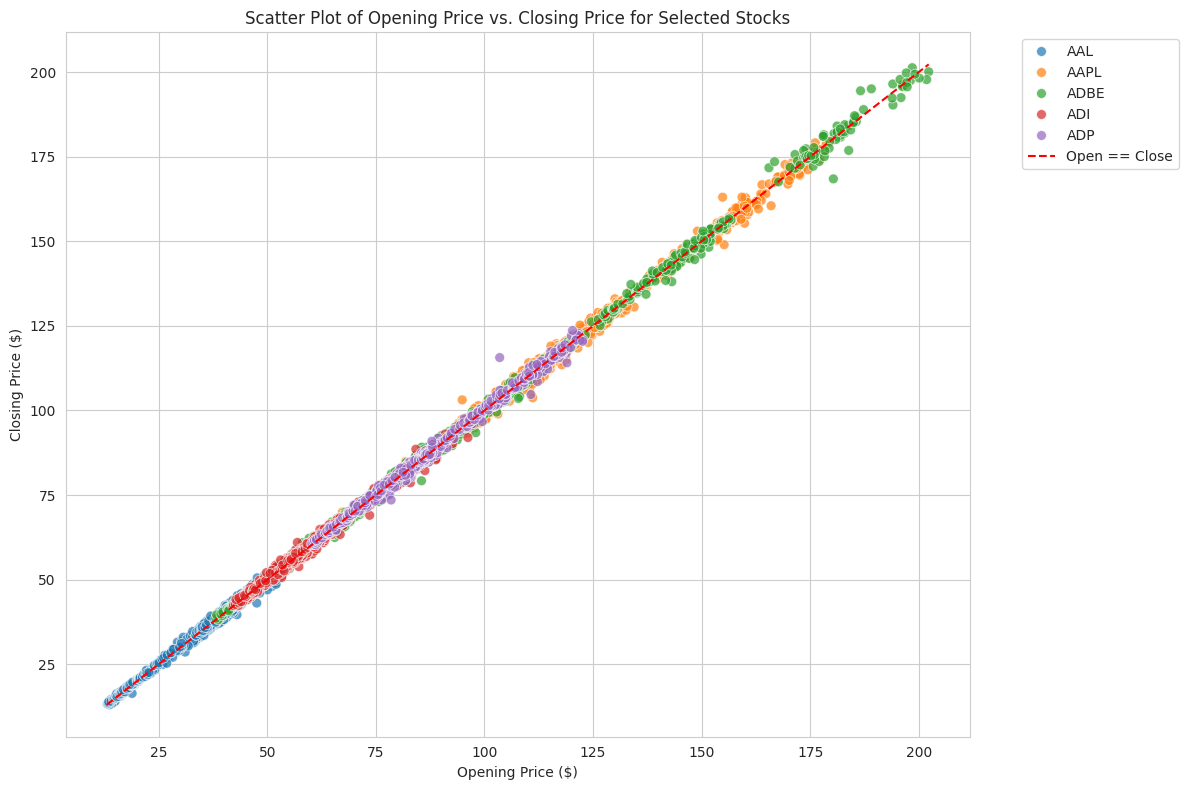

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Select a subset of stocks for better readability
# You can change these names to any other stock symbols present in your DataFrame
selected_stocks = ['AAL', 'AAPL', 'ADBE', 'ADI', 'ADP']
df_subset = df[df['Name'].isin(selected_stocks)].copy()

plt.figure(figsize=(12, 8))
sns.scatterplot(x='open', y='close', data=df_subset, alpha=0.7, hue='Name', legend='full', s=50)

plt.title('Scatter Plot of Opening Price vs. Closing Price for Selected Stocks')
plt.xlabel('Opening Price ($)')
plt.ylabel('Closing Price ($)')

min_val_subset = min(df_subset['open'].min(), df_subset['close'].min())
max_val_subset = max(df_subset['open'].max(), df_subset['close'].max())
plt.plot([min_val_subset, max_val_subset], [min_val_subset, max_val_subset], color='red', linestyle='--', label='Open == Close')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

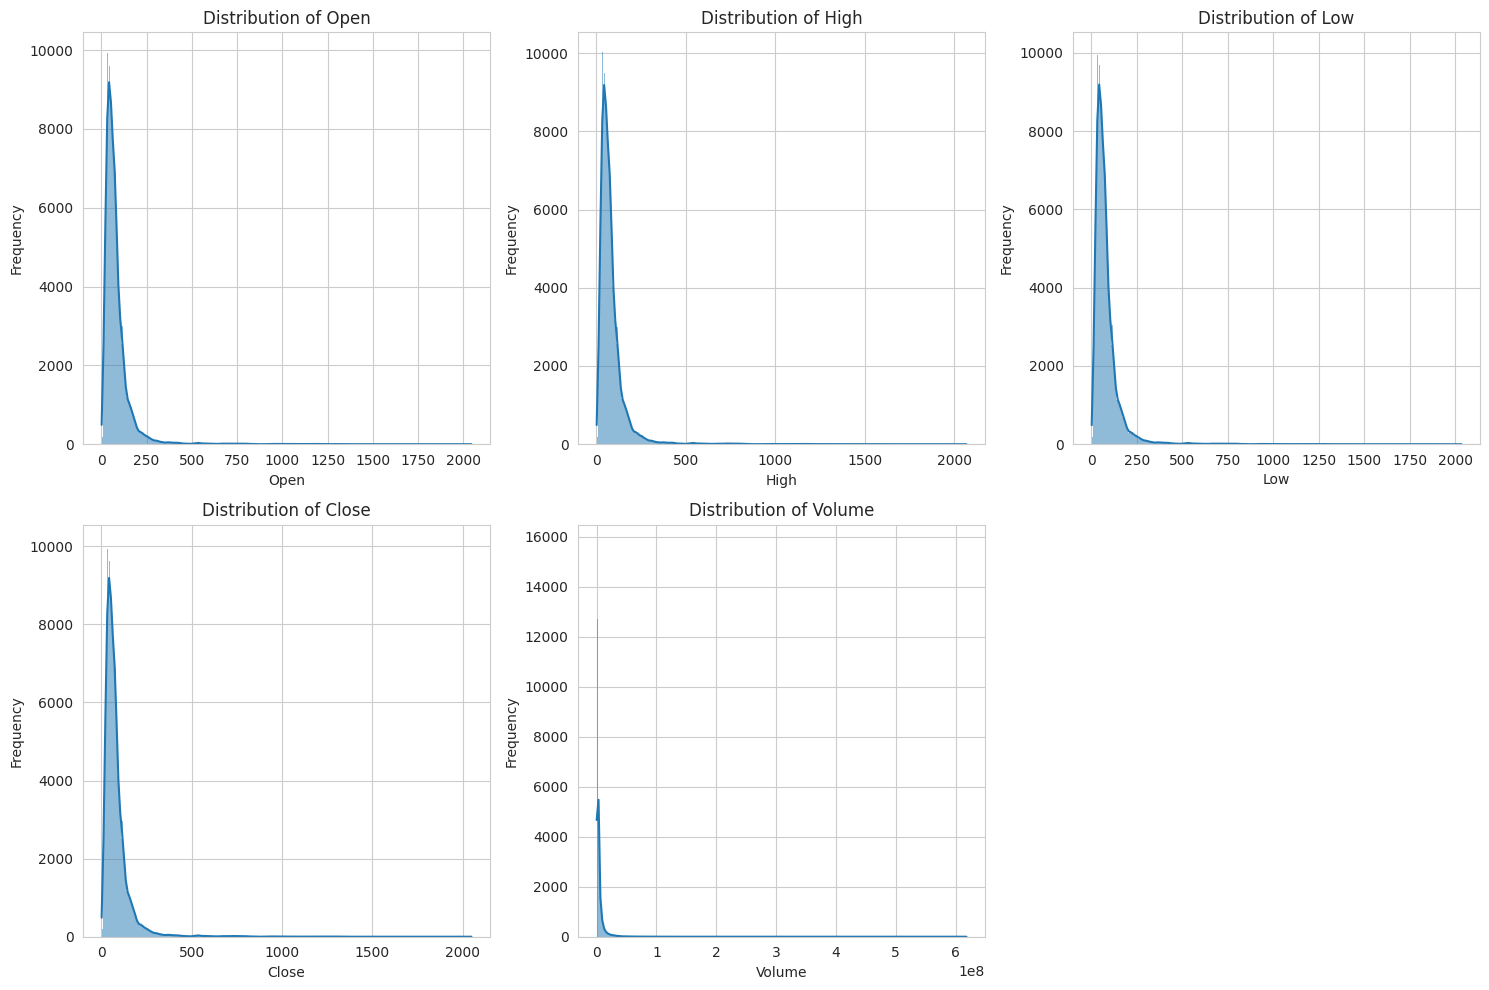

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

numeric_cols_for_dist = ['open', 'high', 'low', 'close', 'volume']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols_for_dist):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col.capitalize()}')
    plt.xlabel(col.capitalize())
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

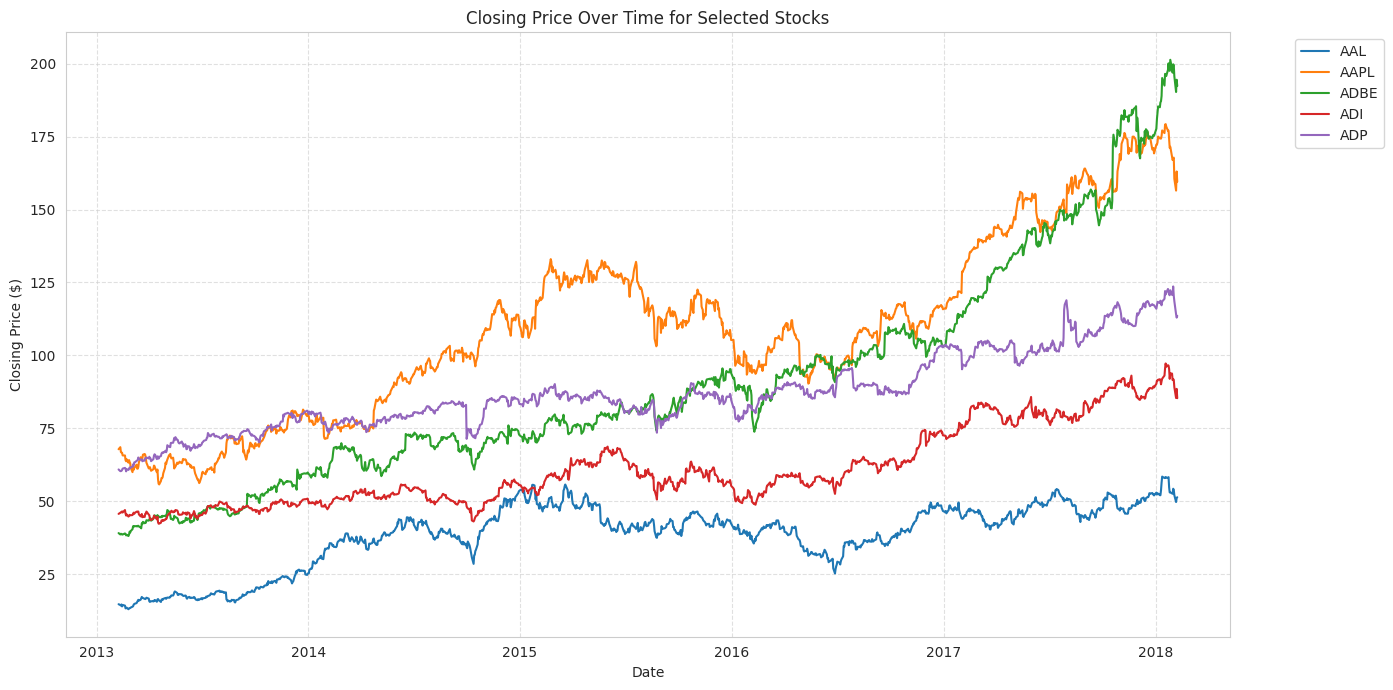

In [11]:
df_subset['date'] = pandas.to_datetime(df_subset['date'])

plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='close', hue='Name', data=df_subset)
plt.title('Closing Price Over Time for Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

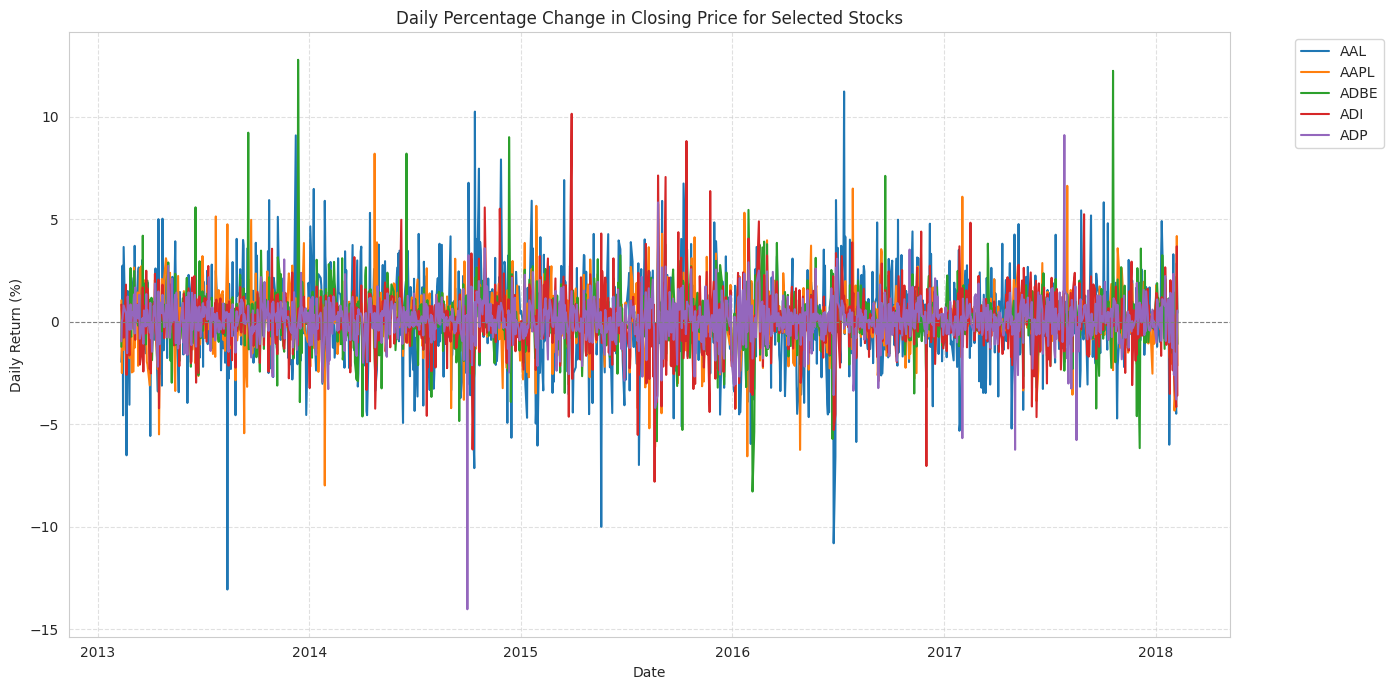

In [12]:
df_subset['daily_return'] = df_subset.groupby('Name')['close'].pct_change() * 100

plt.figure(figsize=(14, 7))
sns.lineplot(x='date', y='daily_return', hue='Name', data=df_subset)
plt.title('Daily Percentage Change in Closing Price for Selected Stocks')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

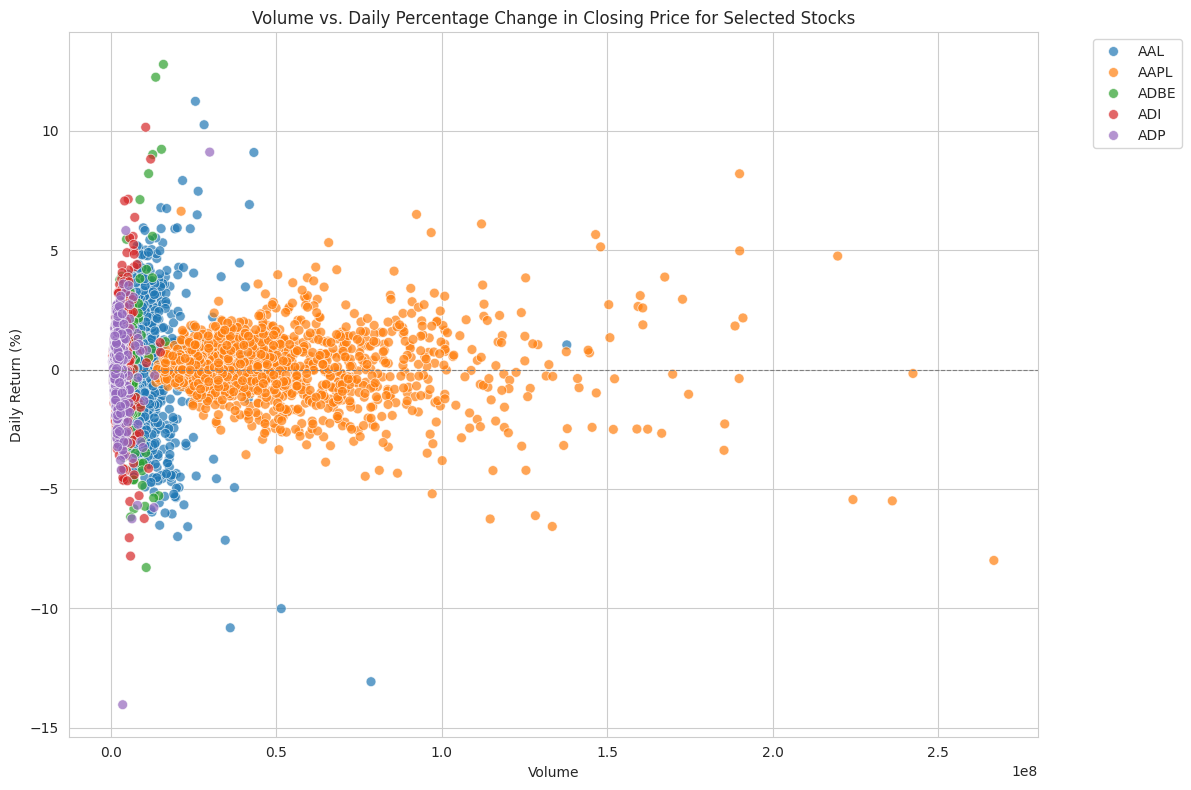

In [13]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x='volume', y='daily_return', hue='Name', data=df_subset, alpha=0.7, s=50)
plt.title('Volume vs. Daily Percentage Change in Closing Price for Selected Stocks')
plt.xlabel('Volume')
plt.ylabel('Daily Return (%)')
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This scatter plot helps visualize the relationship between the daily trading volume and the daily percentage change in closing price. We can observe if higher volumes tend to correlate with larger daily price swings (either positive or negative), which could be an important feature for predicting future stock movements.

# Data information

In [14]:
# Total amount of records
total_records = len(df)
print(f"Total number of records in the DataFrame: {total_records}")

Total number of records in the DataFrame: 619040


In [15]:
# Amount of records for each category (stock Name)
records_per_category = df['Name'].value_counts()
print("\nNumber of records for each stock (category):")
print(records_per_category.to_string())


Number of records for each stock (category):
Name
ZTS      1259
AAL      1259
AAPL     1259
AAP      1259
ABBV     1259
ABC      1259
ABT      1259
ACN      1259
ADBE     1259
WM       1259
WMT      1259
WMB      1259
WHR      1259
WFC      1259
WEC      1259
WDC      1259
WBA      1259
WAT      1259
V        1259
VZ       1259
VTR      1259
VRTX     1259
VRSN     1259
ANTM     1259
ANSS     1259
ANDV     1259
AMZN     1259
AMT      1259
AMP      1259
AMG      1259
AMGN     1259
AME      1259
AMD      1259
AMAT     1259
ALXN     1259
ALL      1259
ALK      1259
ALGN     1259
AYI      1259
AXP      1259
AWK      1259
AVY      1259
AVGO     1259
AVB      1259
ATVI     1259
ARNC     1259
ARE      1259
APH      1259
APD      1259
APC      1259
APA      1259
AOS      1259
AON      1259
BLL      1259
BLK      1259
BK       1259
BIIB     1259
BF.B     1259
BEN      1259
BDX      1259
BBY      1259
BBT      1259
BA       1259
BAX      1259
BAC      1259
A        1259
AZO      1259
CDNS     12

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  object 
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  object 
dtypes: float64(4), int64(1), object(2)
memory usage: 33.1+ MB


There are 5 numeric variables and 2 catergorical variables.
There are also no duplicates

In [17]:
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

outliers_data = {}

print("--- Outlier Detection using IQR Method ---")
for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    if not outliers.empty:
        outliers_data[column] = outliers
        print(f"\nColumn '{column}':")
        print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
        print(f"  Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
        print(f"  Number of outliers: {len(outliers)}")
        print(f"  Examples of outliers (first 5 rows):\n{outliers.head()}")
    else:
        print(f"\nColumn '{column}': No significant outliers detected.")

--- Outlier Detection using IQR Method ---

Column 'open':
  Q1: 40.22, Q3: 94.37, IQR: 54.15
  Lower Bound: -41.01, Upper Bound: 175.60
  Number of outliers: 38963
  Examples of outliers (first 5 rows):
            date    open    high     low   close    volume  Name
2500  2018-01-12  176.18  177.36  175.65  177.09  25418080  AAPL
2501  2018-01-16  177.90  179.39  176.14  176.19  29565947  AAPL
2502  2018-01-17  176.15  179.25  175.07  179.10  34386836  AAPL
2503  2018-01-18  179.37  180.10  178.25  179.26  31193352  AAPL
2504  2018-01-19  178.61  179.58  177.41  178.46  32425067  AAPL

Column 'high':
  Q1: 40.62, Q3: 95.18, IQR: 54.56
  Lower Bound: -41.22, Upper Bound: 177.02
  Number of outliers: 39020
  Examples of outliers (first 5 rows):
            date    open    high     low   close    volume  Name
2483  2017-12-18  174.88  177.20  174.86  176.42  29421114  AAPL
2500  2018-01-12  176.18  177.36  175.65  177.09  25418080  AAPL
2501  2018-01-16  177.90  179.39  176.14  176.19  

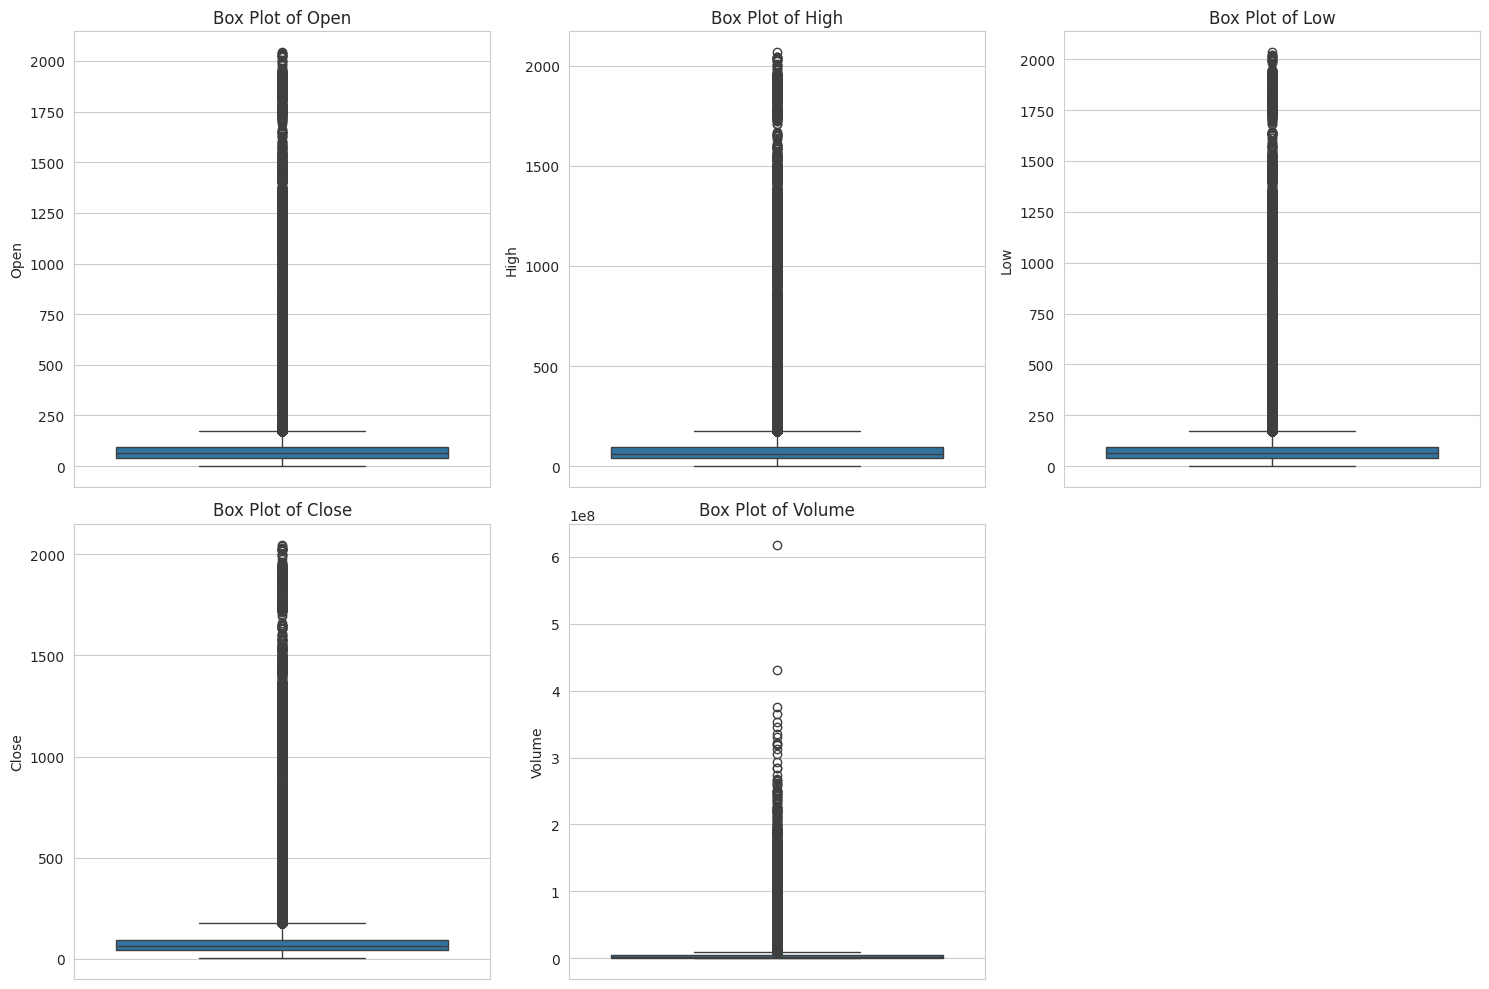

In [18]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col].dropna())
    plt.title(f'Box Plot of {col.capitalize()}')
    plt.ylabel(col.capitalize())

plt.tight_layout()
plt.show()

These box plots visualize the distribution of each numeric feature. The dots outside the 'whiskers' of each box plot represent data points that are statistically identified as outliers by the IQR method. This gives you a clear visual indication of anomalies in each column.

# **Model Training stage 3**

**Step 1: Clean the full dataset and add quality-control checks**

In [19]:
import pandas as pd
import numpy as np

# Make a working copy
model_df = df.copy()

# Convert date to datetime
model_df['date'] = pd.to_datetime(model_df['date'])

# Sort correctly for time-series work
model_df = model_df.sort_values(['Name', 'date']).reset_index(drop=True)

# Count missing values by column
missing_counts = model_df.isnull().sum()

print("Missing values by column:")
print(missing_counts)
print("\nTotal rows before cleaning:", len(model_df))
print("Total stocks:", model_df['Name'].nunique())
print("Date range:", model_df['date'].min(), "to", model_df['date'].max())

# Optional duplicate check
duplicate_count = model_df.duplicated().sum()
print("\nDuplicate rows:", duplicate_count)

# Drop rows missing critical price columns
critical_cols = ['open', 'high', 'low', 'close']
model_df = model_df.dropna(subset=critical_cols).reset_index(drop=True)

print("\nTotal rows after dropping missing critical price rows:", len(model_df))
print("Rows removed:", len(df) - len(model_df))

Missing values by column:
date       0
open      11
high       8
low        8
close      0
volume     0
Name       0
dtype: int64

Total rows before cleaning: 619040
Total stocks: 505
Date range: 2013-02-08 00:00:00 to 2018-02-07 00:00:00

Duplicate rows: 0

Total rows after dropping missing critical price rows: 619029
Rows removed: 11


**Step 2: Create full-dataset daily return and basic engineered features**

In [20]:
# Daily return by stock
model_df['daily_return'] = model_df.groupby('Name')['close'].pct_change() * 100

# Daily price range
model_df['price_range'] = model_df['high'] - model_df['low']

# Simple intraday price change
model_df['open_close_diff'] = model_df['close'] - model_df['open']

print(model_df[['Name', 'date', 'close', 'daily_return', 'price_range', 'open_close_diff']].head(10))

  Name       date  close  daily_return  price_range  open_close_diff
0    A 2013-02-08  45.08           NaN        0.350             0.01
1    A 2013-02-11  44.60     -1.064774        0.730            -0.57
2    A 2013-02-12  44.62      0.044843        0.450            -0.19
3    A 2013-02-13  44.75      0.291349        0.560            -0.06
4    A 2013-02-14  44.58     -0.379888        0.420            -0.14
5    A 2013-02-15  42.25     -5.226559        2.030            -1.23
6    A 2013-02-19  43.01      1.798817        0.910             0.80
7    A 2013-02-20  42.24     -1.790281        0.625            -0.60
8    A 2013-02-21  41.63     -1.444129        0.670            -0.51
9    A 2013-02-22  41.80      0.408359        0.490            -0.03


**Why these features matter(Little explanation guys)**

These already help the model learn:

* how much the stock changed from the prior day
* how volatile the trading day was
* whether price moved up or down during the day

**Step 3: Create the target class**

In [21]:
# Next day's close within each stock
model_df['next_close'] = model_df.groupby('Name')['close'].shift(-1)

# Target: 1 if next day's close is higher, else 0
model_df['next_day_direction'] = (model_df['next_close'] > model_df['close']).astype(int)

# Remove last row of each stock because next_close is missing there
model_df = model_df.dropna(subset=['next_close']).reset_index(drop=True)

print(model_df[['Name', 'date', 'close', 'next_close', 'next_day_direction']].head(10))

print("\nTarget distribution:")
print(model_df['next_day_direction'].value_counts())
print("\nTarget proportions:")
print(model_df['next_day_direction'].value_counts(normalize=True))

  Name       date  close  next_close  next_day_direction
0    A 2013-02-08  45.08       44.60                   0
1    A 2013-02-11  44.60       44.62                   1
2    A 2013-02-12  44.62       44.75                   1
3    A 2013-02-13  44.75       44.58                   0
4    A 2013-02-14  44.58       42.25                   0
5    A 2013-02-15  42.25       43.01                   1
6    A 2013-02-19  43.01       42.24                   0
7    A 2013-02-20  42.24       41.63                   0
8    A 2013-02-21  41.63       41.80                   1
9    A 2013-02-22  41.80       41.29                   0

Target distribution:
next_day_direction
1    322446
0    296078
Name: count, dtype: int64

Target proportions:
next_day_direction
1    0.521315
0    0.478685
Name: proportion, dtype: float64


**This uses:**

* groupby('Name')
* shift(-1)

So each stock is compared only to its own next trading day.

**Step 4: Build the aggregated multi-day features (The comments/suggestions from Professor)**

In [22]:
# Rolling/aggregated features by stock
grouped_close = model_df.groupby('Name')['close']
grouped_return = model_df.groupby('Name')['daily_return']
grouped_volume = model_df.groupby('Name')['volume']

# Lag feature
model_df['return_lag_1'] = grouped_return.shift(1)

# Rolling statistics on close
model_df['close_mean_3'] = grouped_close.transform(lambda x: x.rolling(window=3).mean())
model_df['close_mean_5'] = grouped_close.transform(lambda x: x.rolling(window=5).mean())
model_df['close_max_5'] = grouped_close.transform(lambda x: x.rolling(window=5).max())
model_df['close_min_5'] = grouped_close.transform(lambda x: x.rolling(window=5).min())

# Rolling volatility
model_df['return_std_5'] = grouped_return.transform(lambda x: x.rolling(window=5).std())

# Rolling average volume
model_df['volume_mean_5'] = grouped_volume.transform(lambda x: x.rolling(window=5).mean())

print(model_df[[
    'Name', 'date', 'close', 'daily_return',
    'return_lag_1', 'close_mean_3', 'close_mean_5',
    'close_max_5', 'close_min_5', 'return_std_5', 'volume_mean_5'
]].head(12))

   Name       date  close  daily_return  return_lag_1  close_mean_3  \
0     A 2013-02-08  45.08           NaN           NaN           NaN   
1     A 2013-02-11  44.60     -1.064774           NaN           NaN   
2     A 2013-02-12  44.62      0.044843     -1.064774     44.766667   
3     A 2013-02-13  44.75      0.291349      0.044843     44.656667   
4     A 2013-02-14  44.58     -0.379888      0.291349     44.650000   
5     A 2013-02-15  42.25     -5.226559     -0.379888     43.860000   
6     A 2013-02-19  43.01      1.798817     -5.226559     43.280000   
7     A 2013-02-20  42.24     -1.790281      1.798817     42.500000   
8     A 2013-02-21  41.63     -1.444129     -1.790281     42.293333   
9     A 2013-02-22  41.80      0.408359     -1.444129     41.890000   
10    A 2013-02-25  41.29     -1.220096      0.408359     41.573333   
11    A 2013-02-26  40.97     -0.775006     -1.220096     41.353333   

    close_mean_5  close_max_5  close_min_5  return_std_5  volume_mean_5  
0 

**What these features give us**

They summarize recent history:

* short-term trend
* recent high and low
* recent volatility
* recent trading activity

**Step 5: Remove rows created as NaN by rolling windows:**
Because rolling features need past days, the first few rows of each stock will have missing engineered values.

In [23]:
feature_cols_created = [
    'daily_return', 'price_range', 'open_close_diff',
    'return_lag_1', 'close_mean_3', 'close_mean_5',
    'close_max_5', 'close_min_5', 'return_std_5', 'volume_mean_5'
]

before_drop = len(model_df)
model_df = model_df.dropna(subset=feature_cols_created).reset_index(drop=True)

print("Rows before dropping rolling-feature NaNs:", before_drop)
print("Rows after dropping rolling-feature NaNs:", len(model_df))
print("Rows removed:", before_drop - len(model_df))

Rows before dropping rolling-feature NaNs: 618524
Rows after dropping rolling-feature NaNs: 615999
Rows removed: 2525


# One note about our current notebook for you guys just in case.

Our notebook use:

* df for the raw dataset
* df_subset for EDA plots

That’s fine.

For Stage 3, we will use:

* model_df as the clean modeling dataframe

That keeps things organized and avoids breaking your earlier EDA work.

---
# **Next Stage of Modeling**
**Now we move into:**
* correlation analysis
* feature selection
* symbol-level histograms
* time-based train/test split
* normalization
* Decision Tree, KNN, Naïve Bayes
* evaluation metrics and plots

**Step 6: Correlation analysis**

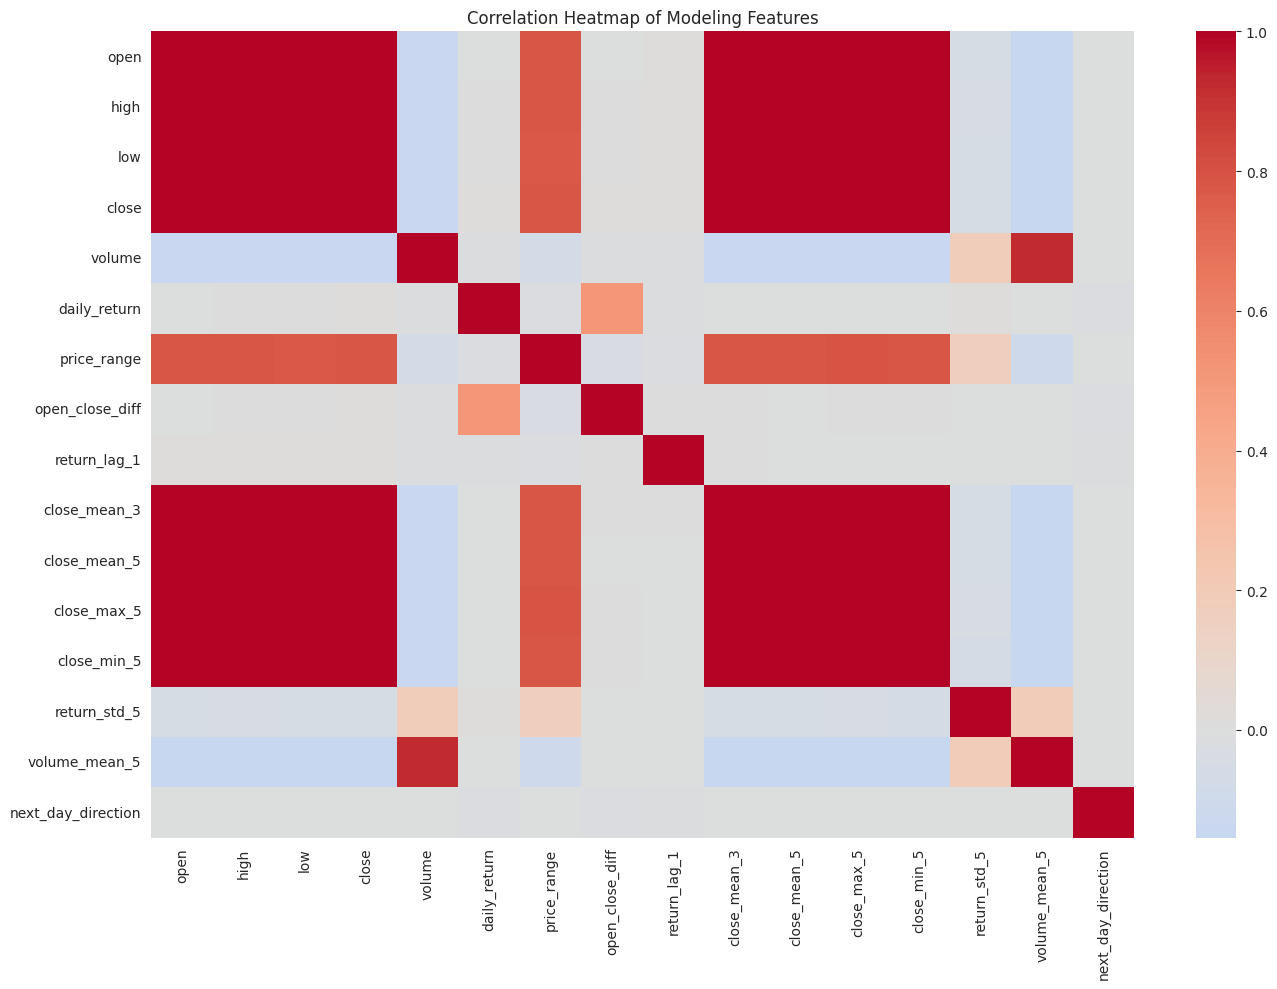

Correlation with target:
next_day_direction    1.000000
close_mean_5          0.000971
close_max_5           0.000966
close_min_5           0.000945
open                  0.000870
close_mean_3          0.000854
low                   0.000754
high                  0.000739
close                 0.000622
price_range          -0.000055
return_std_5         -0.000247
volume               -0.002963
volume_mean_5        -0.004864
return_lag_1         -0.009732
open_close_diff      -0.015527
daily_return         -0.020222
Name: next_day_direction, dtype: float64


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_features = [
    'open', 'high', 'low', 'close', 'volume',
    'daily_return', 'price_range', 'open_close_diff',
    'return_lag_1', 'close_mean_3', 'close_mean_5',
    'close_max_5', 'close_min_5', 'return_std_5', 'volume_mean_5',
    'next_day_direction'
]

corr_matrix = model_df[corr_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Modeling Features')
plt.tight_layout()
plt.show()

# Extra: direct correlation with target
target_corr = corr_matrix['next_day_direction'].sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

**Step 7: Histograms, including symbol level:**
- We will be using one stock with a higher price and one with a lower price. AAPL and AAL should do the job.

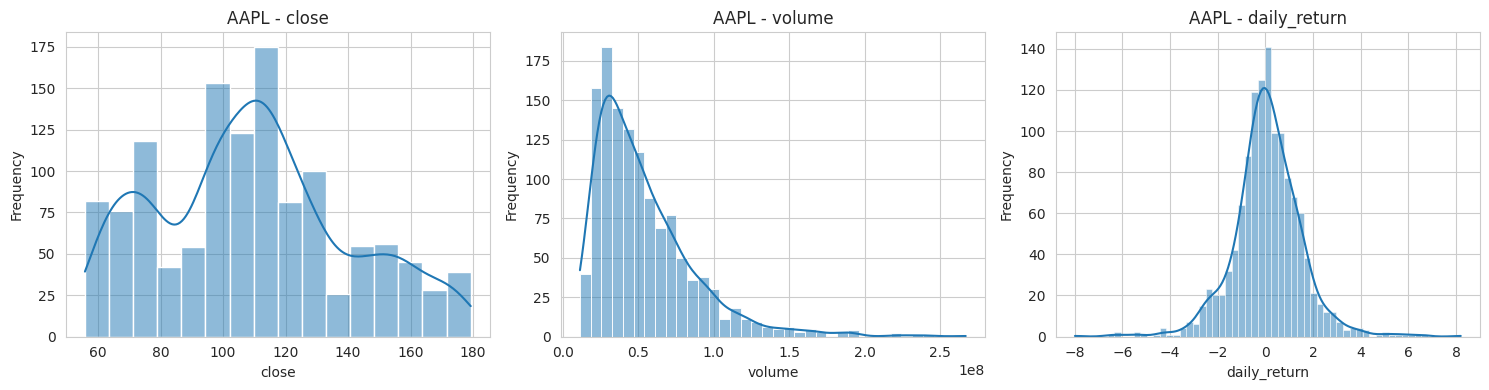

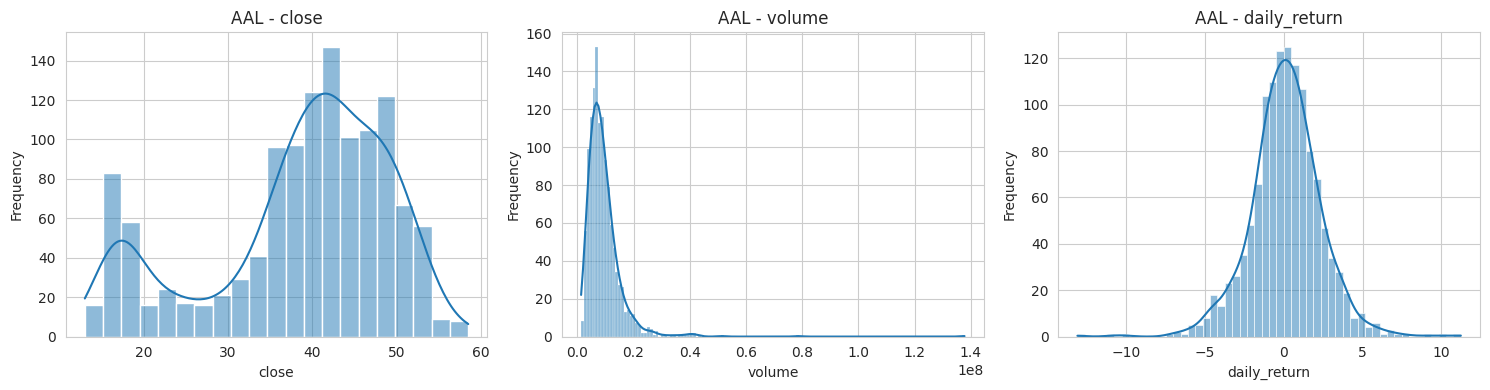

In [25]:
selected_symbol_1 = 'AAPL'
selected_symbol_2 = 'AAL'

symbol_1_df = model_df[model_df['Name'] == selected_symbol_1]
symbol_2_df = model_df[model_df['Name'] == selected_symbol_2]

features_to_plot = ['close', 'volume', 'daily_return']

for symbol, temp_df in [(selected_symbol_1, symbol_1_df), (selected_symbol_2, symbol_2_df)]:
    plt.figure(figsize=(15, 4))

    for i, col in enumerate(features_to_plot, 1):
        plt.subplot(1, 3, i)
        sns.histplot(temp_df[col].dropna(), kde=True)
        plt.title(f'{symbol} - {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

**Why this matters(Little explanation)**

This helps show that:

- different stocks have different price scales
- volume and return distributions vary by stock
- feature distributions are clearer at symbol level

**Step 8: Select the modeling features**

In [26]:
feature_cols = [
    'volume',
    'daily_return',
    'price_range',
    'open_close_diff',
    'return_lag_1',
    'close_mean_3',
    'close_mean_5',
    'close_max_5',
    'close_min_5',
    'return_std_5',
    'volume_mean_5'
]

target_col = 'next_day_direction'

X = model_df[feature_cols].copy()
y = model_df[target_col].copy()

print("Number of selected features:", len(feature_cols))
print("Selected features:")
print(feature_cols)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Number of selected features: 11
Selected features:
['volume', 'daily_return', 'price_range', 'open_close_diff', 'return_lag_1', 'close_mean_3', 'close_mean_5', 'close_max_5', 'close_min_5', 'return_std_5', 'volume_mean_5']

X shape: (615999, 11)
y shape: (615999,)


**Why I left out raw open, high, low, close?**

We have already transformed those into more meaningful features. Using both raw prices and rolling versions can create a lot of redundancy. We can always test a second feature set later.

**Step 9: Time-based split**
- Remember to not use a random split here or in similar datasets. Use earlier dates for training and later dates for testing. We do not wanna mix up a dataset for training when we work with past/future date(time)~(Time_series)

In [27]:
# Sort again just to be safe
model_df = model_df.sort_values(['date', 'Name']).reset_index(drop=True)

# 80/20 split by time order (Standart Split and we also do not wanna have a data leak early in the training, so we are not going to have validation split)
split_index = int(len(model_df) * 0.8)

train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train size:", X_train.shape, y_train.shape)
print("Test size:", X_test.shape, y_test.shape)
print("Train date range:", train_df['date'].min(), "to", train_df['date'].max())
print("Test date range:", test_df['date'].min(), "to", test_df['date'].max())

Train size: (492799, 11) (492799,)
Test size: (123200, 11) (123200,)
Train date range: 2013-02-15 00:00:00 to 2017-02-15 00:00:00
Test date range: 2017-02-15 00:00:00 to 2018-02-06 00:00:00


**Step 10: Normalize for KNN and Naïve Bayes**
- Decision Trees do not need scaling, but KNN definitely does.


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (492799, 11)
Scaled test shape: (123200, 11)


**Step 11: Train the three models**
- **One warning:** KNN on 600k+ rows can be slow. We’ll still code it properly, but if runtime gets heavy, we may reduce the training size just for KNN.

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# KNN - start with a few k values
k_values = [3, 5, 7, 9]
knn_models = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    knn_models[k] = knn

print("Models trained successfully.")

Models trained successfully.


**Step 12: Finally - Evaluating the models**
- This code cell takes a good chunk of time to compute and finish so make sure you wait to see the results.


--- Decision Tree ---
Accuracy: 0.5179
Precision: 0.5288
Recall: 0.7438
F1 Score: 0.6181


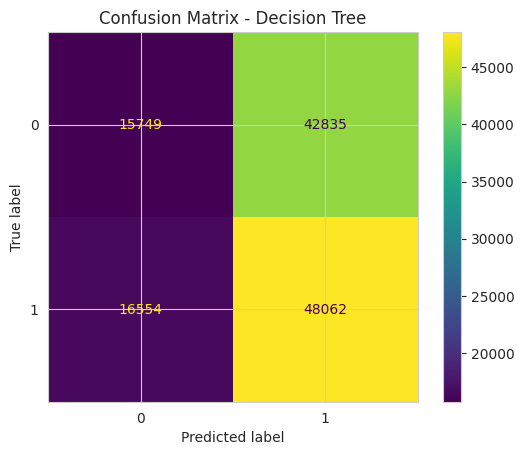

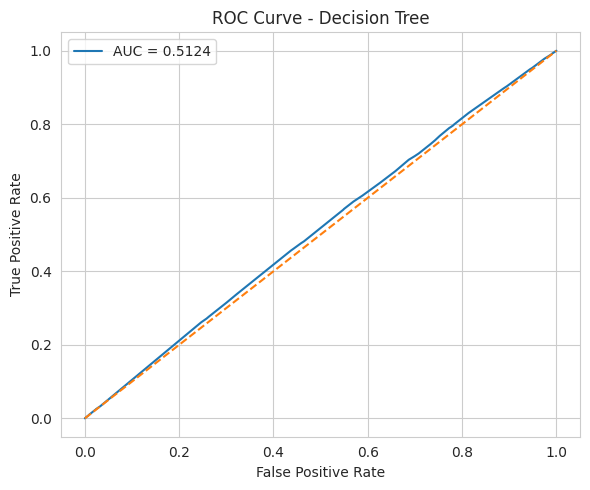

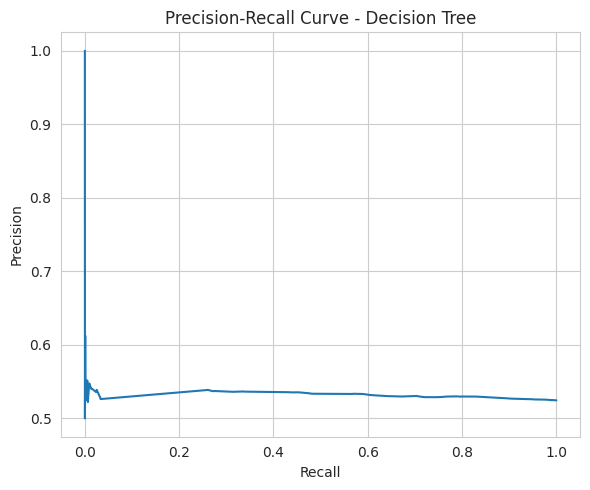


--- Naive Bayes ---
Accuracy: 0.5196
Precision: 0.5251
Recall: 0.8768
F1 Score: 0.6569


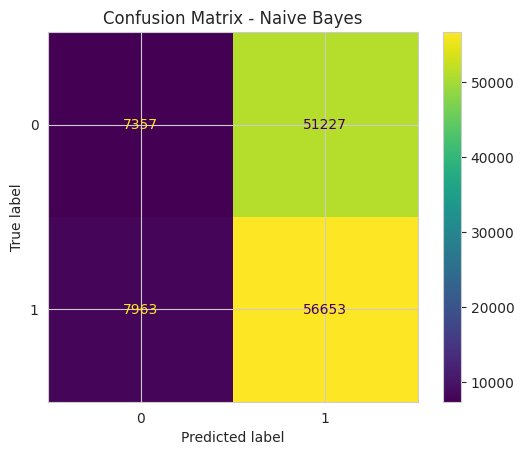

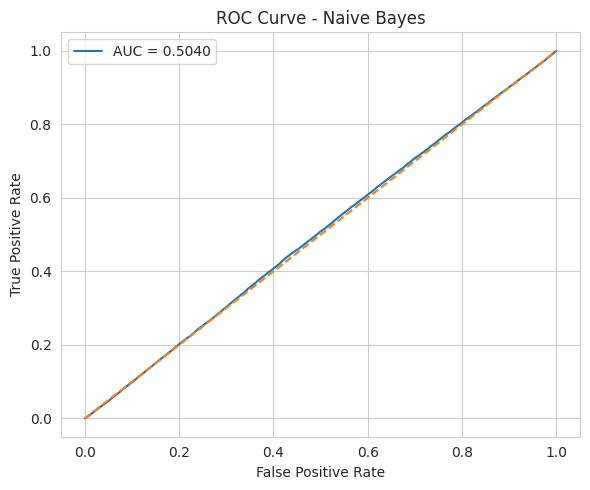

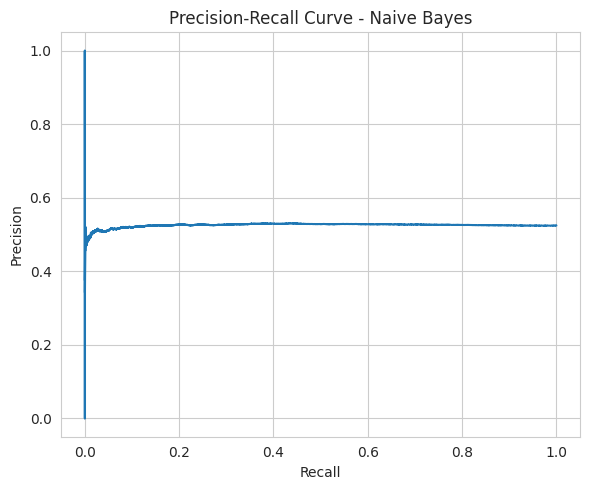


--- KNN (k=3) ---
Accuracy: 0.5051
Precision: 0.5282
Recall: 0.5295
F1 Score: 0.5288


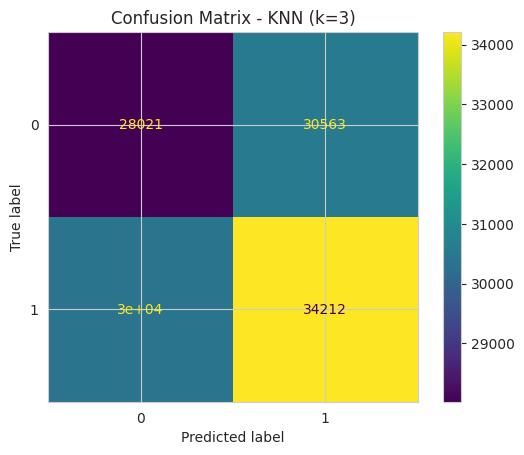

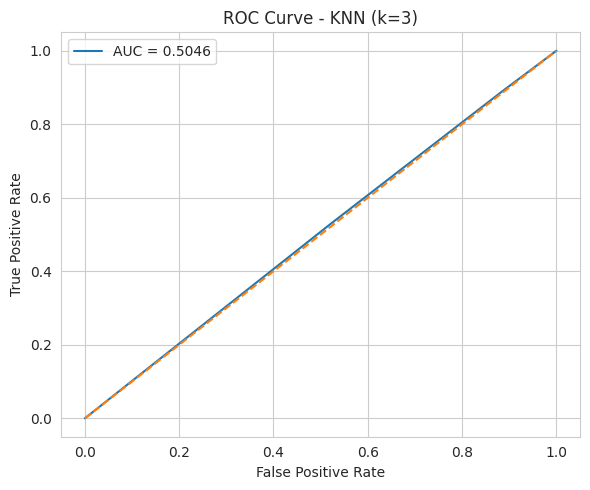

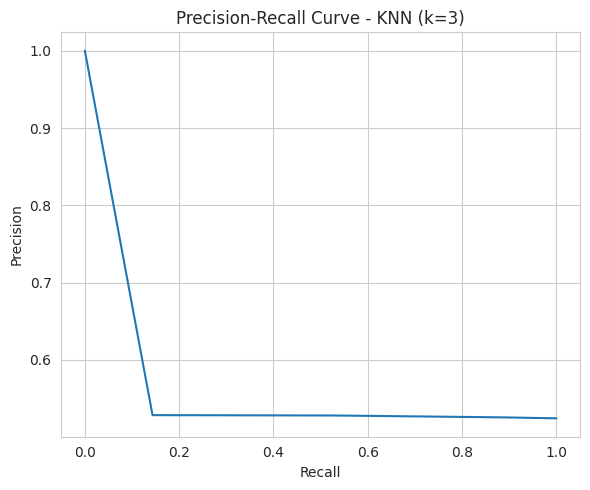


--- KNN (k=5) ---
Accuracy: 0.5038
Precision: 0.5266
Recall: 0.5347
F1 Score: 0.5306


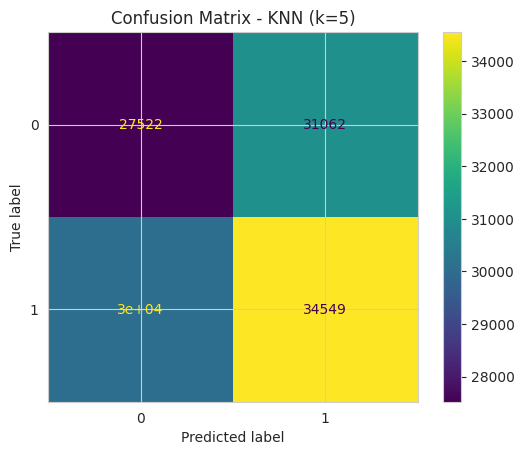

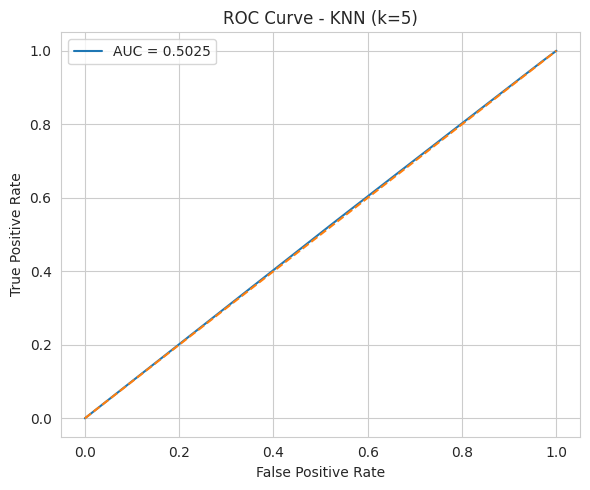

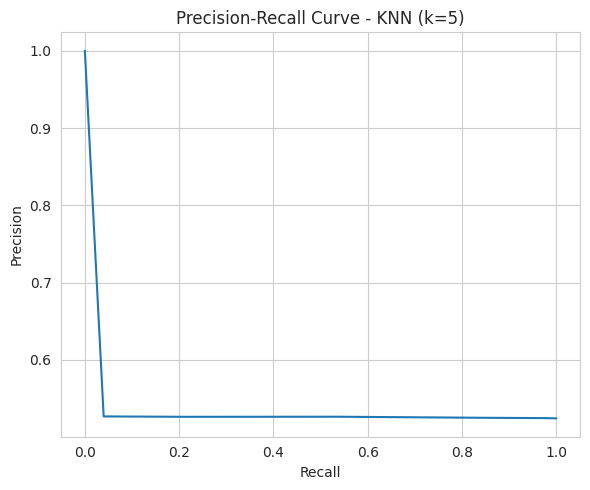


--- KNN (k=7) ---
Accuracy: 0.5044
Precision: 0.5268
Recall: 0.5418
F1 Score: 0.5342


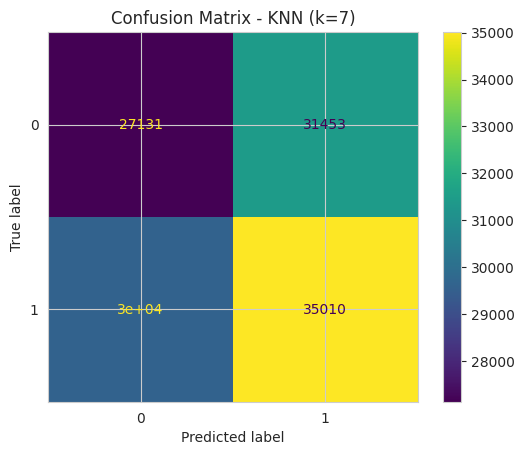

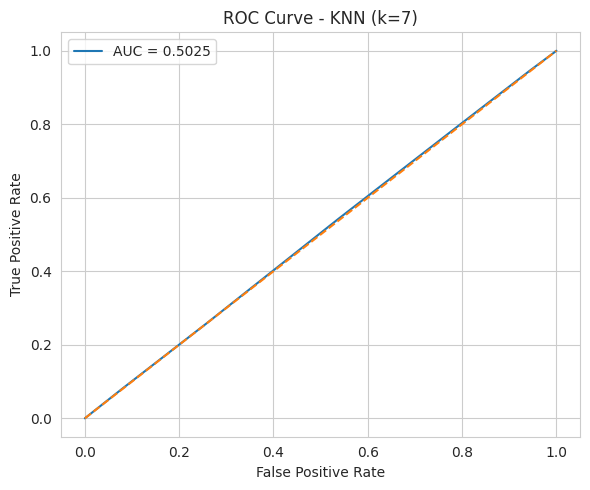

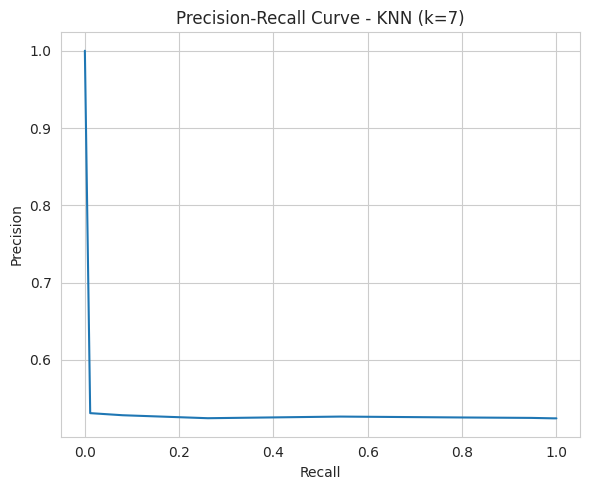


--- KNN (k=9) ---
Accuracy: 0.504
Precision: 0.5262
Recall: 0.5459
F1 Score: 0.5359


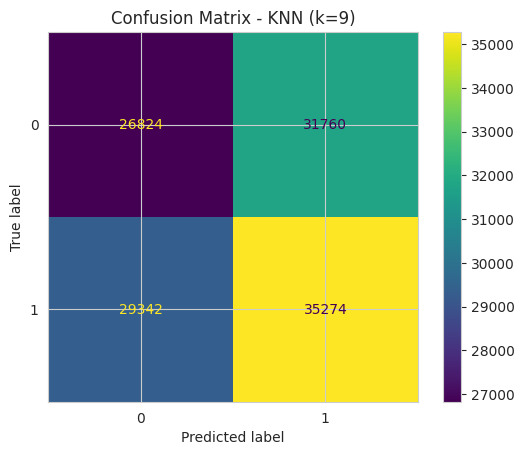

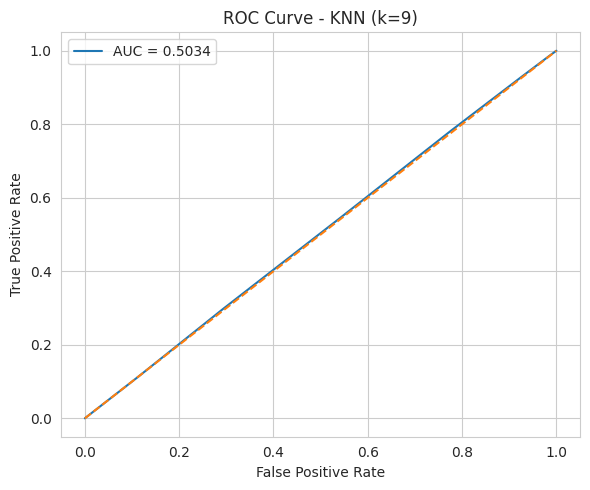

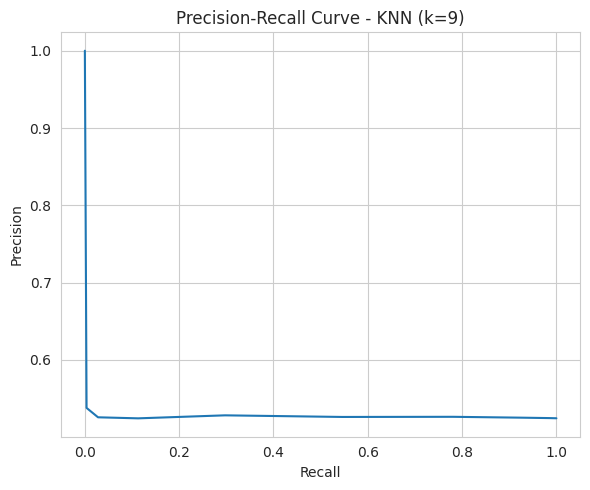

In [30]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)

def evaluate_model(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))

    cm = confusion_matrix(y_test_data, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    precision_vals, recall_vals, _ = precision_recall_curve(y_test_data, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall_vals, precision_vals)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.tight_layout()
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc_auc
    }

results = []

results.append(evaluate_model(dt_model, X_test, y_test, "Decision Tree"))
results.append(evaluate_model(nb_model, X_test_scaled, y_test, "Naive Bayes"))

for k, knn_model in knn_models.items():
    results.append(evaluate_model(knn_model, X_test_scaled, y_test, f"KNN (k={k})"))

**Step 13: Compare model performance in one table**

In [31]:
import pandas as pd

results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print(results_df)

           Model  Accuracy  Precision    Recall        F1   ROC_AUC
1    Naive Bayes  0.519562   0.525148  0.876764  0.656862  0.503998
0  Decision Tree  0.517946   0.528752  0.743810  0.618109  0.512423
2      KNN (k=3)  0.505138   0.528167  0.529466  0.528816  0.504555
4      KNN (k=7)  0.504391   0.526759  0.541816  0.534182  0.502477
5      KNN (k=9)  0.504042   0.526211  0.545902  0.535875  0.503381
3      KNN (k=5)  0.503823   0.526573  0.534682  0.530597  0.502502


---
## Stage 3 Model Improvement Note

The modeling work above represents our first complete baseline pipeline for Stage 3.  
These earlier training results do not prevent further tuning or feature improvement.

We are continuing in the same notebook because:

- the current workflow is already correct and complete for the required course stage
- the notebook now serves as a record of our baseline results
- we can compare improved features and revised models directly against the first version

The next section will focus on improving feature engineering rather than starting from scratch.  
In particular, I plan to replace or supplement absolute price-based features with more relative and behavior-based features, since the first model results suggest that the current features contain only weak predictive signal.

For clarity, the improved version will use separate variable names where needed and will be re-trained from scratch.  
Before final submission, the notebook should be restarted and run from top to bottom to confirm that the final outputs are clean and reproducible.

Step 1 - Create refined relative / momentum features

In [32]:
# Make a new copy so we keep this improvement round separate
model_df_v2 = model_df.copy()

# Grouped series
grouped_return_v2 = model_df_v2.groupby('Name')['daily_return']
grouped_close_v2 = model_df_v2.groupby('Name')['close']
grouped_volume_v2 = model_df_v2.groupby('Name')['volume']

# Additional lagged returns
model_df_v2['return_lag_2'] = grouped_return_v2.shift(2)
model_df_v2['return_lag_3'] = grouped_return_v2.shift(3)

# Rolling return summaries
model_df_v2['return_mean_3'] = grouped_return_v2.transform(lambda x: x.rolling(window=3).mean())
model_df_v2['return_mean_5'] = grouped_return_v2.transform(lambda x: x.rolling(window=5).mean())
model_df_v2['return_max_5'] = grouped_return_v2.transform(lambda x: x.rolling(window=5).max())
model_df_v2['return_min_5'] = grouped_return_v2.transform(lambda x: x.rolling(window=5).min())

# Relative price position vs recent averages
model_df_v2['close_vs_mean_3'] = (model_df_v2['close'] / model_df_v2['close_mean_3']) - 1
model_df_v2['close_vs_mean_5'] = (model_df_v2['close'] / model_df_v2['close_mean_5']) - 1

# Relative daily range
model_df_v2['range_pct'] = model_df_v2['price_range'] / model_df_v2['close']

# Relative volume vs recent average
model_df_v2['volume_ratio_5'] = model_df_v2['volume'] / model_df_v2['volume_mean_5']

# Optional sign-style feature for intraday move
model_df_v2['intraday_return_pct'] = (model_df_v2['close'] - model_df_v2['open']) / model_df_v2['open'] * 100

print(model_df_v2[[
    'Name', 'date', 'close', 'daily_return',
    'return_lag_2', 'return_lag_3',
    'return_mean_3', 'return_mean_5',
    'return_max_5', 'return_min_5',
    'close_vs_mean_3', 'close_vs_mean_5',
    'range_pct', 'volume_ratio_5', 'intraday_return_pct'
]].head(12))

    Name       date    close  daily_return  return_lag_2  return_lag_3  \
0      A 2013-02-15  42.2500     -5.226559           NaN           NaN   
1    AAL 2013-02-15  14.5000      3.645461           NaN           NaN   
2    AAP 2013-02-15  79.0000      0.202943           NaN           NaN   
3   AAPL 2013-02-15  65.7371     -1.377979           NaN           NaN   
4   ABBV 2013-02-15  37.5800      2.761827           NaN           NaN   
5    ABC 2013-02-15  46.6000     -0.363481           NaN           NaN   
6    ABT 2013-02-15  35.0800      1.095101           NaN           NaN   
7    ACN 2013-02-15  74.1600      1.408451           NaN           NaN   
8   ADBE 2013-02-15  38.6350      0.064750           NaN           NaN   
9    ADI 2013-02-15  46.1750     -0.784272           NaN           NaN   
10   ADM 2013-02-15  32.5700      3.726115           NaN           NaN   
11   ADP 2013-02-15  61.2200      0.790254           NaN           NaN   

    return_mean_3  return_mean_5  ret

**Step 2 - Drop rows with NaNs from the new features**

In [33]:
new_feature_cols_v2 = [
    'return_lag_2',
    'return_lag_3',
    'return_mean_3',
    'return_mean_5',
    'return_max_5',
    'return_min_5',
    'close_vs_mean_3',
    'close_vs_mean_5',
    'range_pct',
    'volume_ratio_5',
    'intraday_return_pct'
]

before_drop_v2 = len(model_df_v2)
model_df_v2 = model_df_v2.dropna(subset=new_feature_cols_v2).reset_index(drop=True)

print("Rows before dropping new-feature NaNs:", before_drop_v2)
print("Rows after dropping new-feature NaNs:", len(model_df_v2))
print("Rows removed:", before_drop_v2 - len(model_df_v2))

Rows before dropping new-feature NaNs: 615999
Rows after dropping new-feature NaNs: 613979
Rows removed: 2020


**Step 3 - Select the refined feature set**

In [34]:
feature_cols_v2 = [
    'daily_return',
    'return_lag_1',
    'return_lag_2',
    'return_lag_3',
    'return_mean_3',
    'return_mean_5',
    'return_max_5',
    'return_min_5',
    'return_std_5',
    'close_vs_mean_3',
    'close_vs_mean_5',
    'range_pct',
    'volume_ratio_5',
    'intraday_return_pct'
]

target_col_v2 = 'next_day_direction'

X_v2 = model_df_v2[feature_cols_v2].copy()
y_v2 = model_df_v2[target_col_v2].copy()

print("Number of refined features:", len(feature_cols_v2))
print("Refined features:")
print(feature_cols_v2)
print("\nX_v2 shape:", X_v2.shape)
print("y_v2 shape:", y_v2.shape)

Number of refined features: 14
Refined features:
['daily_return', 'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_mean_3', 'return_mean_5', 'return_max_5', 'return_min_5', 'return_std_5', 'close_vs_mean_3', 'close_vs_mean_5', 'range_pct', 'volume_ratio_5', 'intraday_return_pct']

X_v2 shape: (613979, 14)
y_v2 shape: (613979,)


**Step 4 - Use a clean date cutoff split**

In [35]:
cutoff_date = pd.Timestamp('2017-02-15')

train_df_v2 = model_df_v2[model_df_v2['date'] < cutoff_date].copy()
test_df_v2 = model_df_v2[model_df_v2['date'] >= cutoff_date].copy()

X_train_v2 = train_df_v2[feature_cols_v2]
y_train_v2 = train_df_v2[target_col_v2]

X_test_v2 = test_df_v2[feature_cols_v2]
y_test_v2 = test_df_v2[target_col_v2]

print("Train size:", X_train_v2.shape, y_train_v2.shape)
print("Test size:", X_test_v2.shape, y_test_v2.shape)
print("Train date range:", train_df_v2['date'].min(), "to", train_df_v2['date'].max())
print("Test date range:", test_df_v2['date'].min(), "to", test_df_v2['date'].max())

Train size: (490367, 14) (490367,)
Test size: (123612, 14) (123612,)
Train date range: 2013-02-22 00:00:00 to 2017-02-14 00:00:00
Test date range: 2017-02-15 00:00:00 to 2018-02-06 00:00:00


**Step 5 - Scale the refined features**

In [36]:
from sklearn.preprocessing import StandardScaler

scaler_v2 = StandardScaler()

X_train_v2_scaled = scaler_v2.fit_transform(X_train_v2)
X_test_v2_scaled = scaler_v2.transform(X_test_v2)

print("Scaled training shape:", X_train_v2_scaled.shape)
print("Scaled test shape:", X_test_v2_scaled.shape)

Scaled training shape: (490367, 14)
Scaled test shape: (123612, 14)


**Step 6 - Add a baseline model**


In [37]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

dummy_model = DummyClassifier(strategy='most_frequent')
dummy_model.fit(X_train_v2, y_train_v2)

dummy_pred = dummy_model.predict(X_test_v2)
dummy_accuracy = accuracy_score(y_test_v2, dummy_pred)

print("Baseline Dummy Accuracy:", round(dummy_accuracy, 4))
print("Majority class predicted by baseline:", dummy_model.constant if hasattr(dummy_model, 'constant') else "most_frequent")

Baseline Dummy Accuracy: 0.5242
Majority class predicted by baseline: None


**Step 7 - Train the refined models**
- We’ll keep the same required models.
To save time, let’s start with fewer KNN values.

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Decision Tree
dt_model_v2 = DecisionTreeClassifier(random_state=42, max_depth=8)
dt_model_v2.fit(X_train_v2, y_train_v2)

# Naive Bayes
nb_model_v2 = GaussianNB()
nb_model_v2.fit(X_train_v2_scaled, y_train_v2)

# KNN
k_values_v2 = [5, 9]
knn_models_v2 = {}

for k in k_values_v2:
    knn_v2 = KNeighborsClassifier(n_neighbors=k)
    knn_v2.fit(X_train_v2_scaled, y_train_v2)
    knn_models_v2[k] = knn_v2

print("Refined models trained successfully.")

Refined models trained successfully.


**Step 8 - Evaluate the refined models**


--- Decision Tree v2 ---
Accuracy: 0.517
Precision: 0.5289
Recall: 0.7189
F1 Score: 0.6095


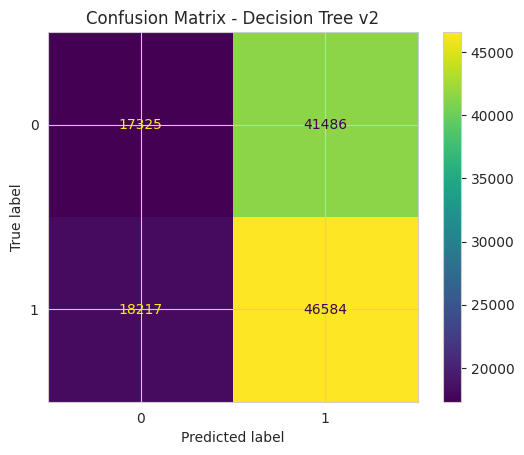

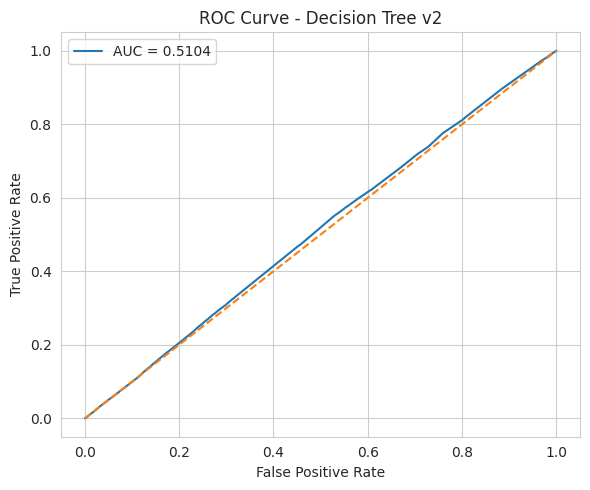

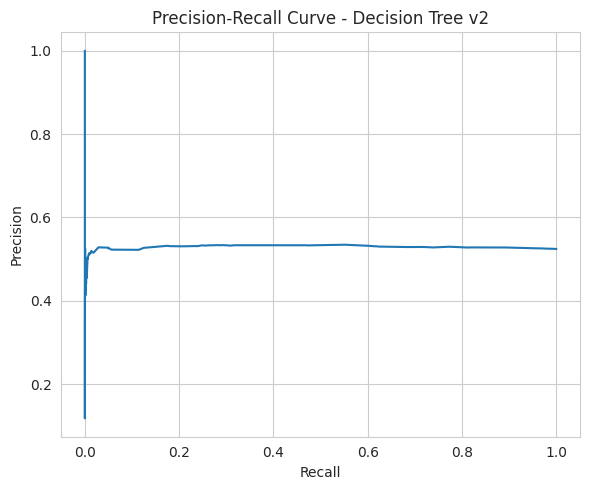


--- Naive Bayes v2 ---
Accuracy: 0.5021
Precision: 0.5279
Recall: 0.4748
F1 Score: 0.4999


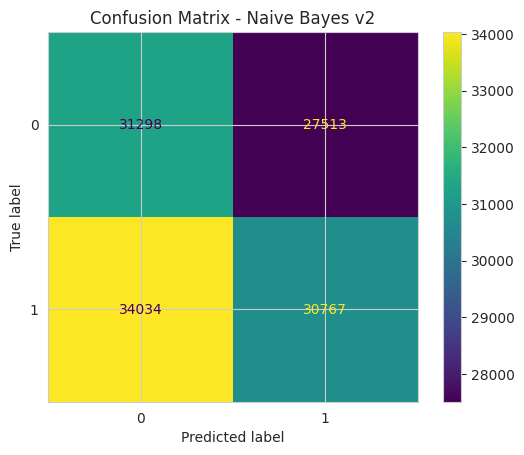

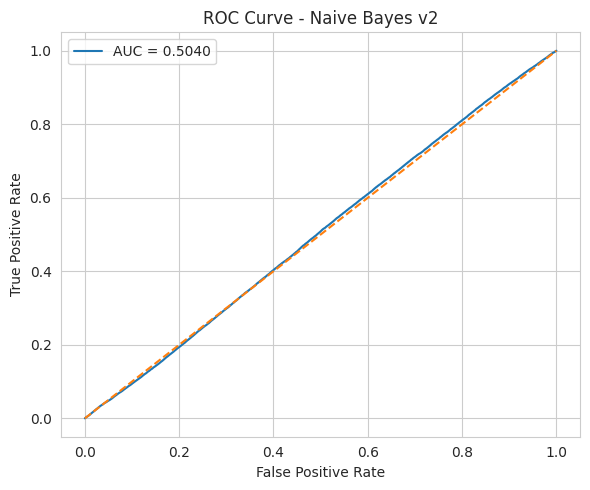

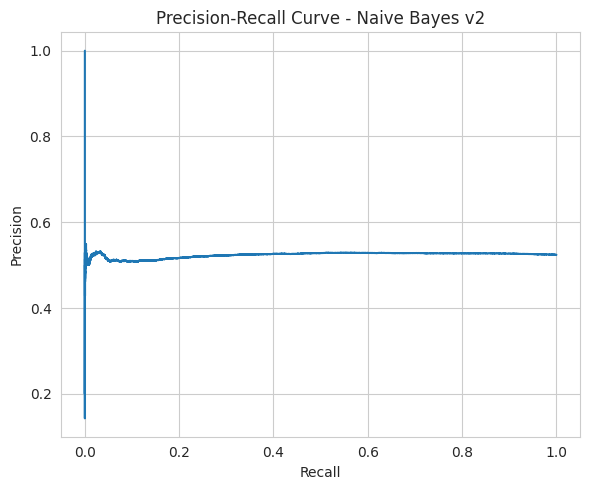


--- KNN v2 (k=5) ---
Accuracy: 0.5023
Precision: 0.5249
Recall: 0.5335
F1 Score: 0.5292


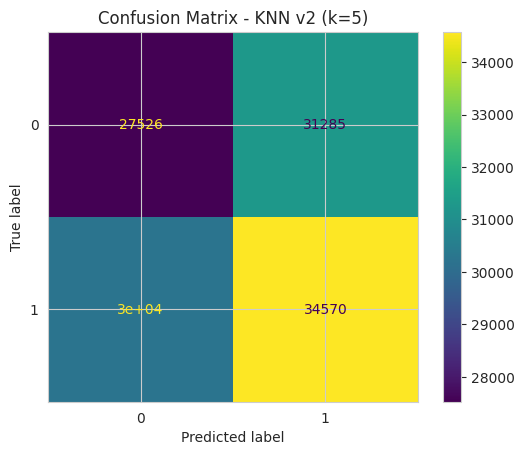

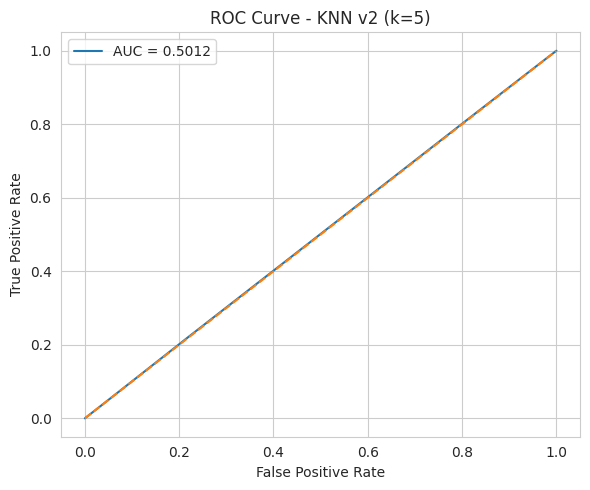

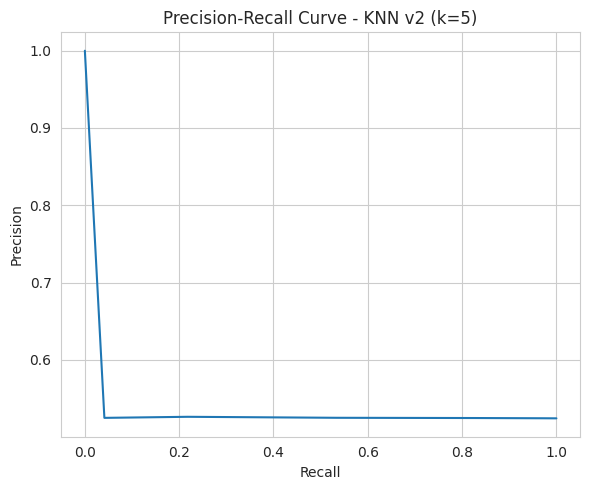


--- KNN v2 (k=9) ---
Accuracy: 0.5027
Precision: 0.5249
Recall: 0.5426
F1 Score: 0.5336


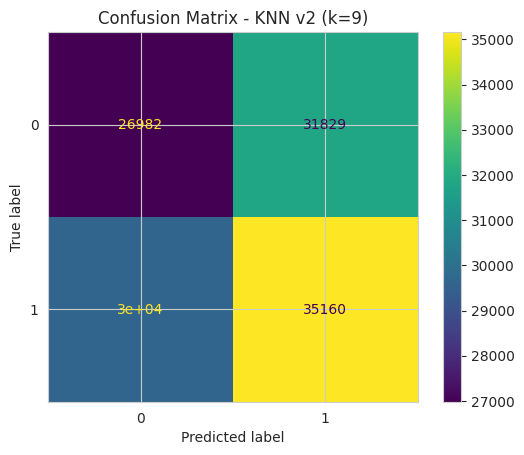

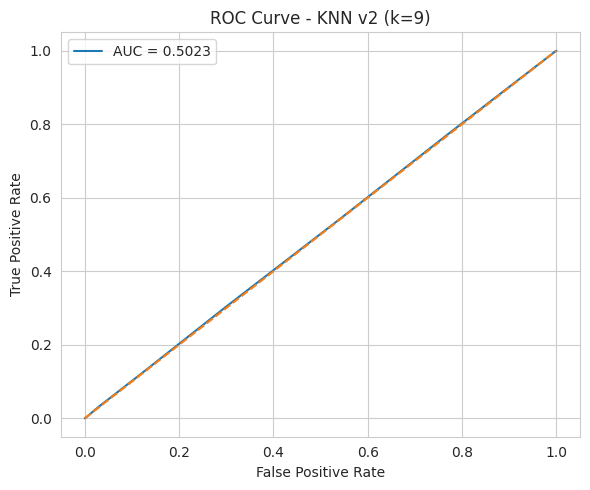

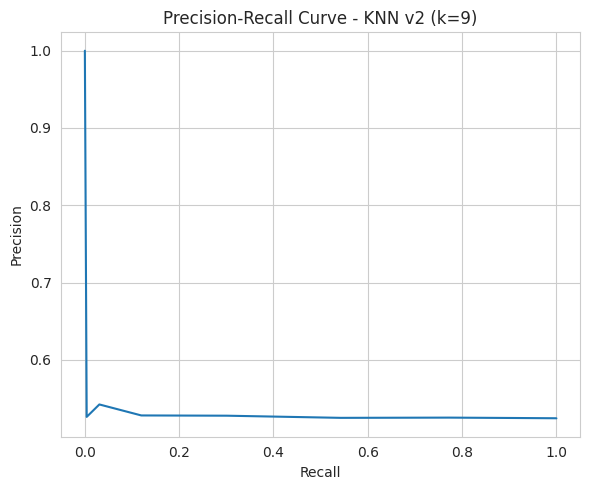

In [39]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)

def evaluate_model_v2(model, X_test_data, y_test_data, model_name):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:, 1]

    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred)
    rec = recall_score(y_test_data, y_pred)
    f1 = f1_score(y_test_data, y_pred)

    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1 Score:", round(f1, 4))

    cm = confusion_matrix(y_test_data, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    fpr, tpr, _ = roc_curve(y_test_data, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    precision_vals, recall_vals, _ = precision_recall_curve(y_test_data, y_prob)

    plt.figure(figsize=(6, 5))
    plt.plot(recall_vals, precision_vals)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.tight_layout()
    plt.show()

    return {
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC_AUC': roc_auc
    }

results_v2 = []

results_v2.append({
    'Model': 'Dummy Baseline',
    'Accuracy': accuracy_score(y_test_v2, dummy_pred),
    'Precision': np.nan,
    'Recall': np.nan,
    'F1': np.nan,
    'ROC_AUC': np.nan
})

results_v2.append(evaluate_model_v2(dt_model_v2, X_test_v2, y_test_v2, "Decision Tree v2"))
results_v2.append(evaluate_model_v2(nb_model_v2, X_test_v2_scaled, y_test_v2, "Naive Bayes v2"))

for k, knn_model_v2 in knn_models_v2.items():
    results_v2.append(evaluate_model_v2(knn_model_v2, X_test_v2_scaled, y_test_v2, f"KNN v2 (k={k})"))

**Step 9 - Compare the refined results**

In [40]:
results_v2_df = pd.DataFrame(results_v2).sort_values(by='Accuracy', ascending=False)
print(results_v2_df)

              Model  Accuracy  Precision    Recall        F1   ROC_AUC
0    Dummy Baseline  0.524229        NaN       NaN       NaN       NaN
1  Decision Tree v2  0.517013   0.528943  0.718878  0.609455  0.510373
4      KNN v2 (k=9)  0.502718   0.524862  0.542584  0.533576  0.502297
3      KNN v2 (k=5)  0.502346   0.524941  0.533479  0.529176  0.501230
2    Naive Bayes v2  0.502095   0.527917  0.474792  0.499947  0.503985
